<h1 align="center"> Python Essentials: Data Visualization.</h1>

    <Name>
    <Class>
    <Date>

In [26]:
import numpy as np
from scipy.special import binom
from scipy.stats import linregress
from matplotlib import colors, pyplot as plt

In [3]:
plt.rcParams["figure.dpi"] = 300     # Raise figure quality.

### Problem 1

The file `anscombe.npy` contains Anscombe’s quartet.
For each section of the quartet,
- Plot the data as a scatter plot on the box [0, 20] × [0, 13].
- Use `scipy.stats.linregress()` to calculate the slope and intercept of the least squares regression line for the data and its correlation coefficient (the first three return values).
- Plot the least squares regression line over the scatter plot on the domain $x\in[0,20]$.
- Report (print) the mean and variance in $x$ and $y$, the slope and intercept of the regression line, and the correlation coefficient. Compare these statistics to those of the other sections.
- Describe how the section is similar to the others and how it is different.

I
Slope:  0.5000909090909091
Intercept:  3.0000909090909103
Correlation:  0.8164205163448399
Variance:  0.11790550059563408
Mean: ( 9.0 , 7.500909090909093 )

II
Slope:  0.5000000000000001
Intercept:  3.000909090909089
Correlation:  0.816236506000243
Variance:  0.11796374596764074
Mean: ( 9.0 , 7.50090909090909 )

III
Slope:  0.4997272727272729
Intercept:  3.002454545454544
Correlation:  0.8162867394895984
Variance:  0.11787766222100221
Mean: ( 9.0 , 7.5 )

IV
Slope:  0.4999090909090909
Intercept:  3.0017272727272726
Correlation:  0.8165214368885028
Variance:  0.11781894172968553
Mean: ( 9.0 , 7.500909090909091 )



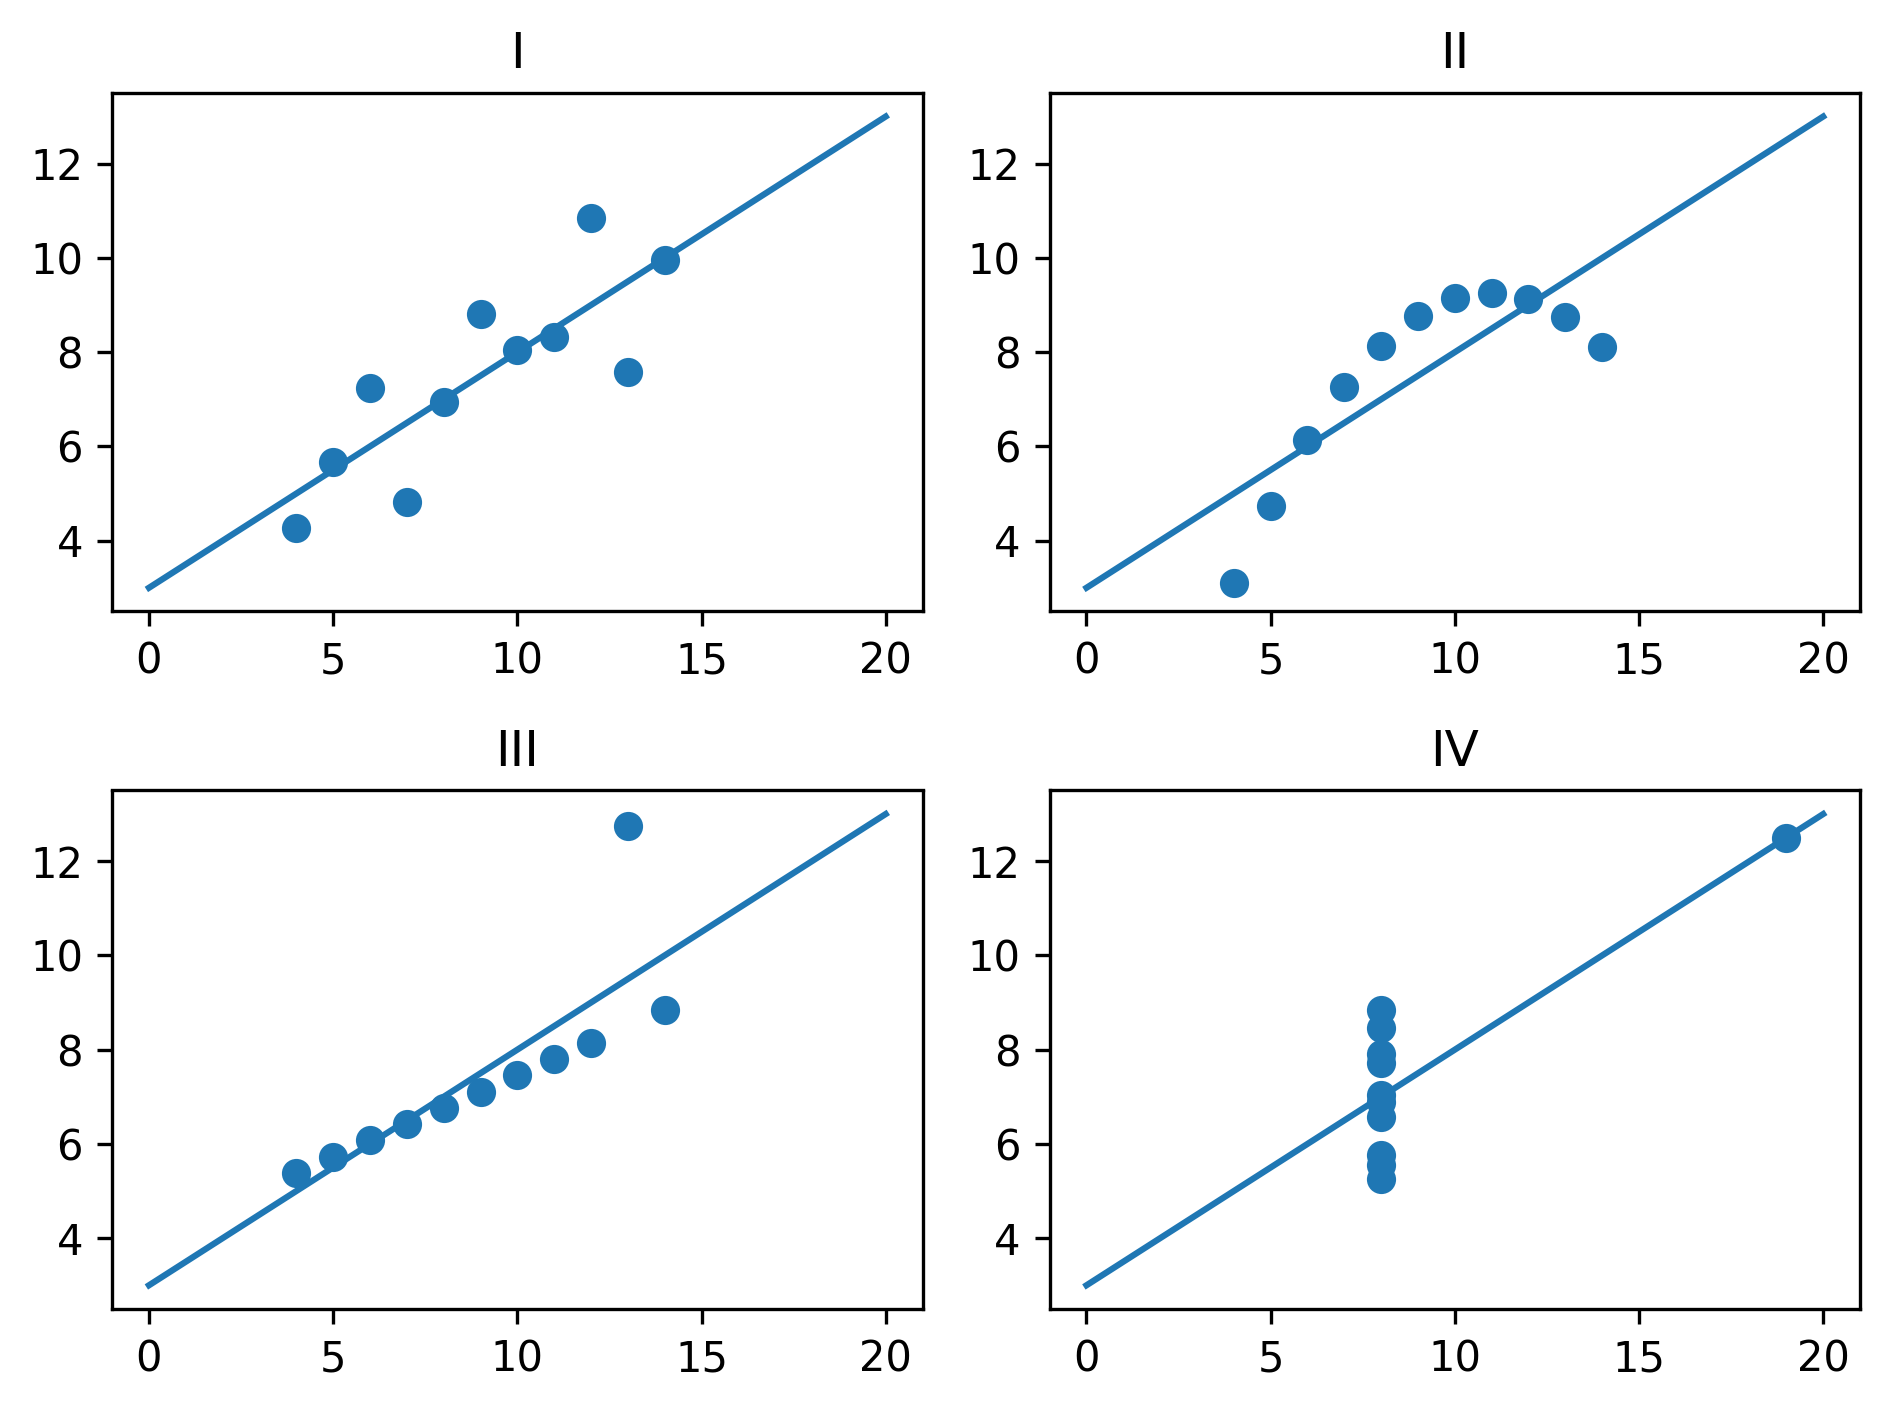

In [4]:
A = np.load("anscombe.npy") # I don't know hwat anscombe means
titles = ["I", "II", "III", "IV"] # Don't know what these really mean either
for i in range(4):
    plt.subplot(2, 2, i + 1)
    x = A[:, 2 * i] 
    y = A[:, (2 * i) + 1] # This one was fun
    plt.scatter(x, y) # Easy dubs
    plt.title(titles[i])
    m, b, correlation, p_value, standard_error = linregress(x, y) # So many variables
    plt.plot(np.linspace(0, 20, 10000), np.linspace(0, 20, 10000) * m + b) # mx + b for the win
    print(titles[i])
    print("Slope: ", m)
    print("Intercept: ", b)
    print("Correlation: ", correlation)
    print("Variance: ", standard_error)
    print("Mean: (", np.mean(x), ",", np.mean(y), ")\n")
plt.tight_layout() # Don't know why this isn't default
plt.show()


### Problem 2
The $n + 1$ Bernstein basis polynomials of degree $n$ are defined as follows.

$$b_{n,v}(x) = \binom{n}{v}x^v(1-x)^{n-v},\quad v=0,\ 1,\ \ldots,\ n$$

Plot the first $10$ Bernstein basis polynomials ($n = 0,\ 1,\ 2,\ 3$) as small multiples on the domain $[0, 1] \times [0, 1]$.
Label the subplots for clarity, adjust tick marks and labels for simplicity, and set the window limits of
each plot to be the same.
Consider arranging the subplots so that the rows correspond with $n$ and the columns with $v$.

(Hint: The constant $\binom{n}{v} = \frac{n!}{v!(n-v)!}$ is called the binomial coefficient and can be efficiently computed with `scipy.special.binom()` or `scipy.special.comb()`.)

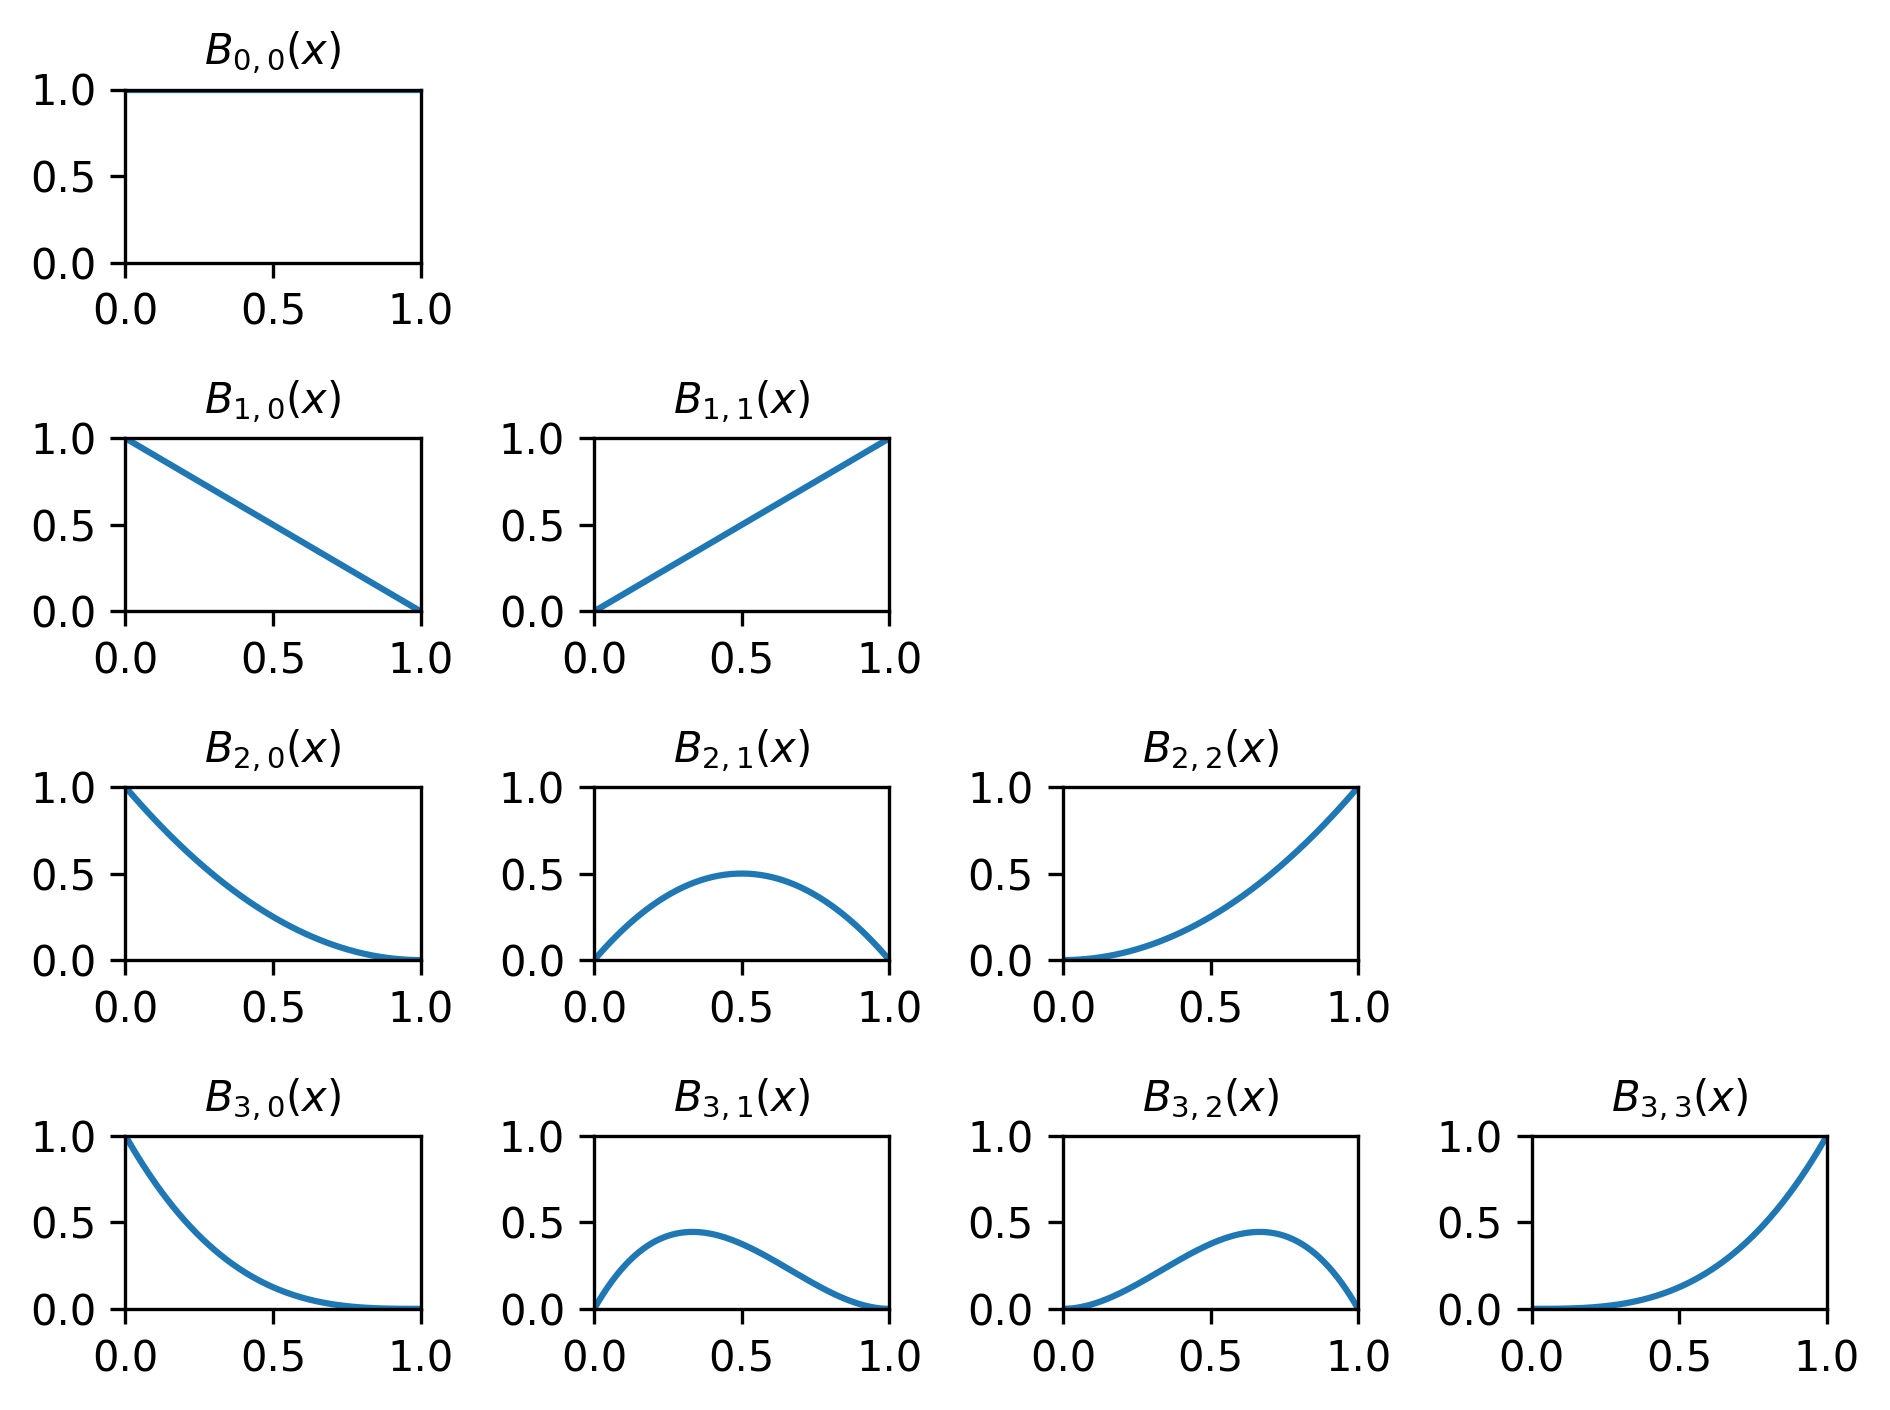

In [5]:
xs = np.linspace(0, 1, 200)

for n in range(4):
    for v in range(n+1):
        plt.subplot(4, 4, n*4 + v + 1)  # Weird grid indexing
        ys = binom(n, v) * xs**v * (1 - xs)**(n - v) # Bernstein polynomial
        plt.plot(xs, ys)
        plt.axis([0, 1, 0, 1])
        plt.title(f"$B_{{{n},{v}}}(x)$", fontsize=10)

plt.tight_layout()
plt.show()



### Problem 3

The file `MLB.npy` contains measurements from over 1,000 recent Major League Baseball players, compiled by UCLA.
Each row in the array represents a different player; the columns are the player’s height (in inches), weight (in pounds), and age (in years), in that order.

Create several visualizations to show the correlations between height, weight, and age in the MLB data set.
Use at least one scatter plot.
Adjust the marker size, plot a regression line, change the window limits, and use small multiples where appropriate.

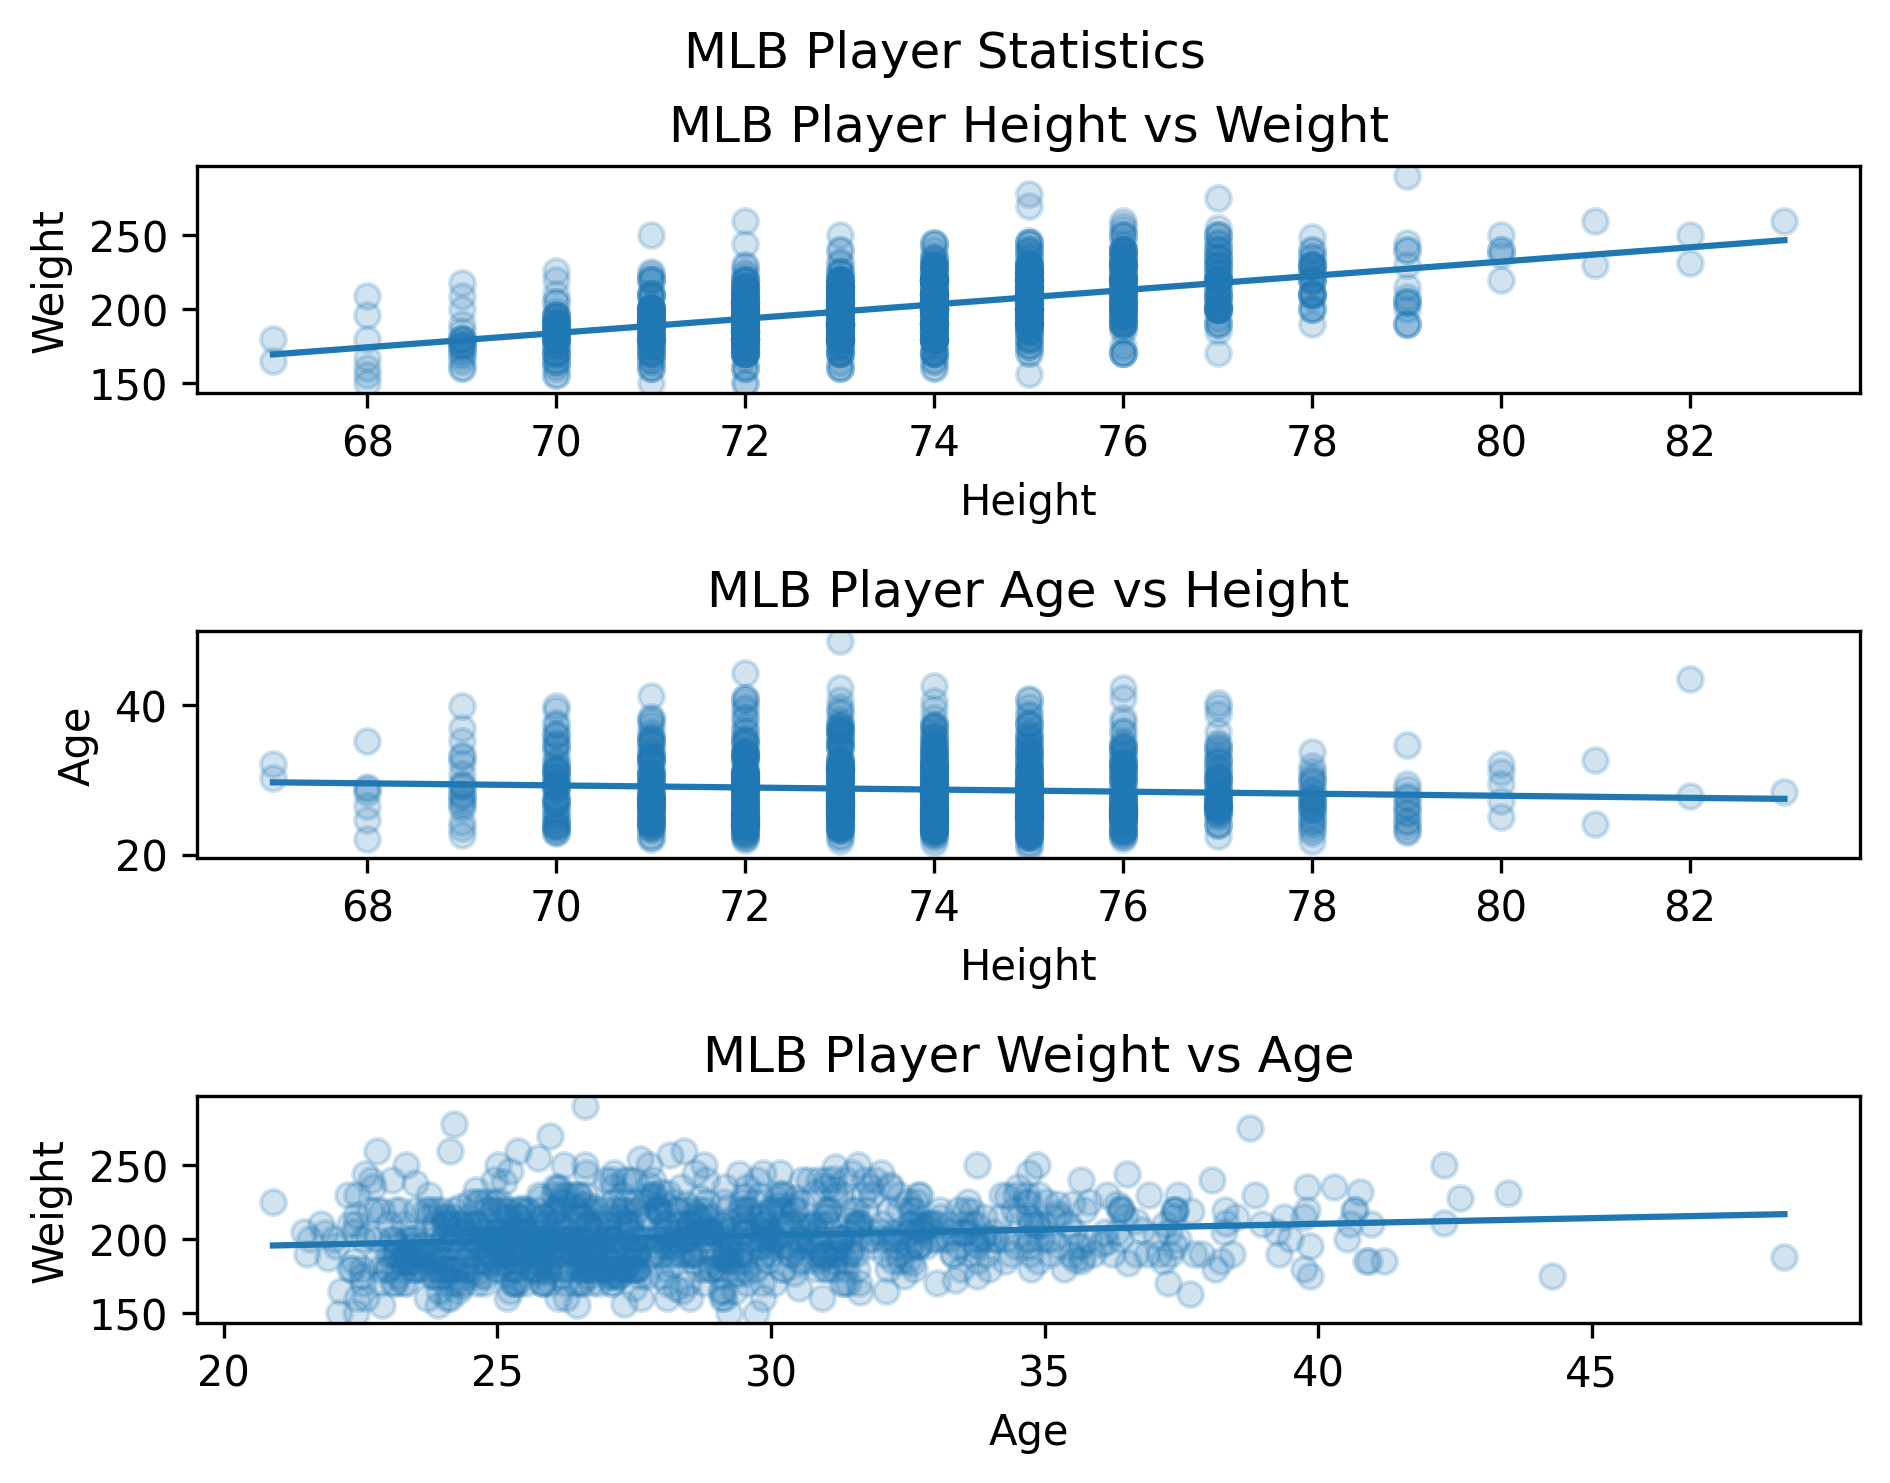

In [15]:
height, weight, age = np.load("MLB.npy").T # The transpose felt right

# Height vs Weight
plt.subplot(3, 1, 1)
plt.scatter(height, weight, alpha=0.2)
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("MLB Player Height vs Weight")
m, b, _, _, _ = linregress(height, weight) # Still don't like these variables
xs = np.linspace(np.min(height), np.max(height), 10000)
plt.plot(xs, xs * m + b)

# Height vs Age
plt.subplot(3, 1, 2)
plt.scatter(height, age, alpha=0.2)
plt.xlabel("Height")
plt.ylabel("Age")
plt.title("MLB Player Age vs Height")
m, b, _, _, _ = linregress(height, age)
xs = np.linspace(np.min(height), np.max(height), 10000)
plt.plot(xs, xs * m + b) # mx + b for the win

# Age vs Weight
plt.subplot(3, 1, 3)
plt.scatter(age, weight, alpha=0.2)
plt.xlabel("Age")
plt.ylabel("Weight")
plt.title("MLB Player Weight vs Age")
m, b, _, _, _ = linregress(age, weight) # So many variables
xs = np.linspace(np.min(age), np.max(age), 10000)
plt.plot(xs, xs * m + b) # mx + b for the win

plt.tight_layout()
plt.suptitle("MLB Player Statistics", y=1.02)
plt.show()

### Problem 4

The file `earthquakes.npy` contains data from over 17,000 earthquakes between 2000 and 2010 that were at least a 5 on the Richter scale.
Each row in the array represents a different earthquake; the columns are the earthquake’s date (as a fraction of the year), magnitude (on the Richter scale), longitude, and latitude, in that order.

Describe the data with at least two better visualizations. Include line plots, scatter plots, and histograms as appropriate.
Your plots should answer the following questions:
1. How many earthquakes happened every year?
2. How often do stronger earthquakes happen compared to weaker ones?
3. Where do earthquakes happen? Where do the strongest earthquakes happen?

Hint: Use `plt.axis("equal")` or `ax.set_aspect("equal")` to fix the aspect ratio, which may improve comparisons between longitude and latitude.

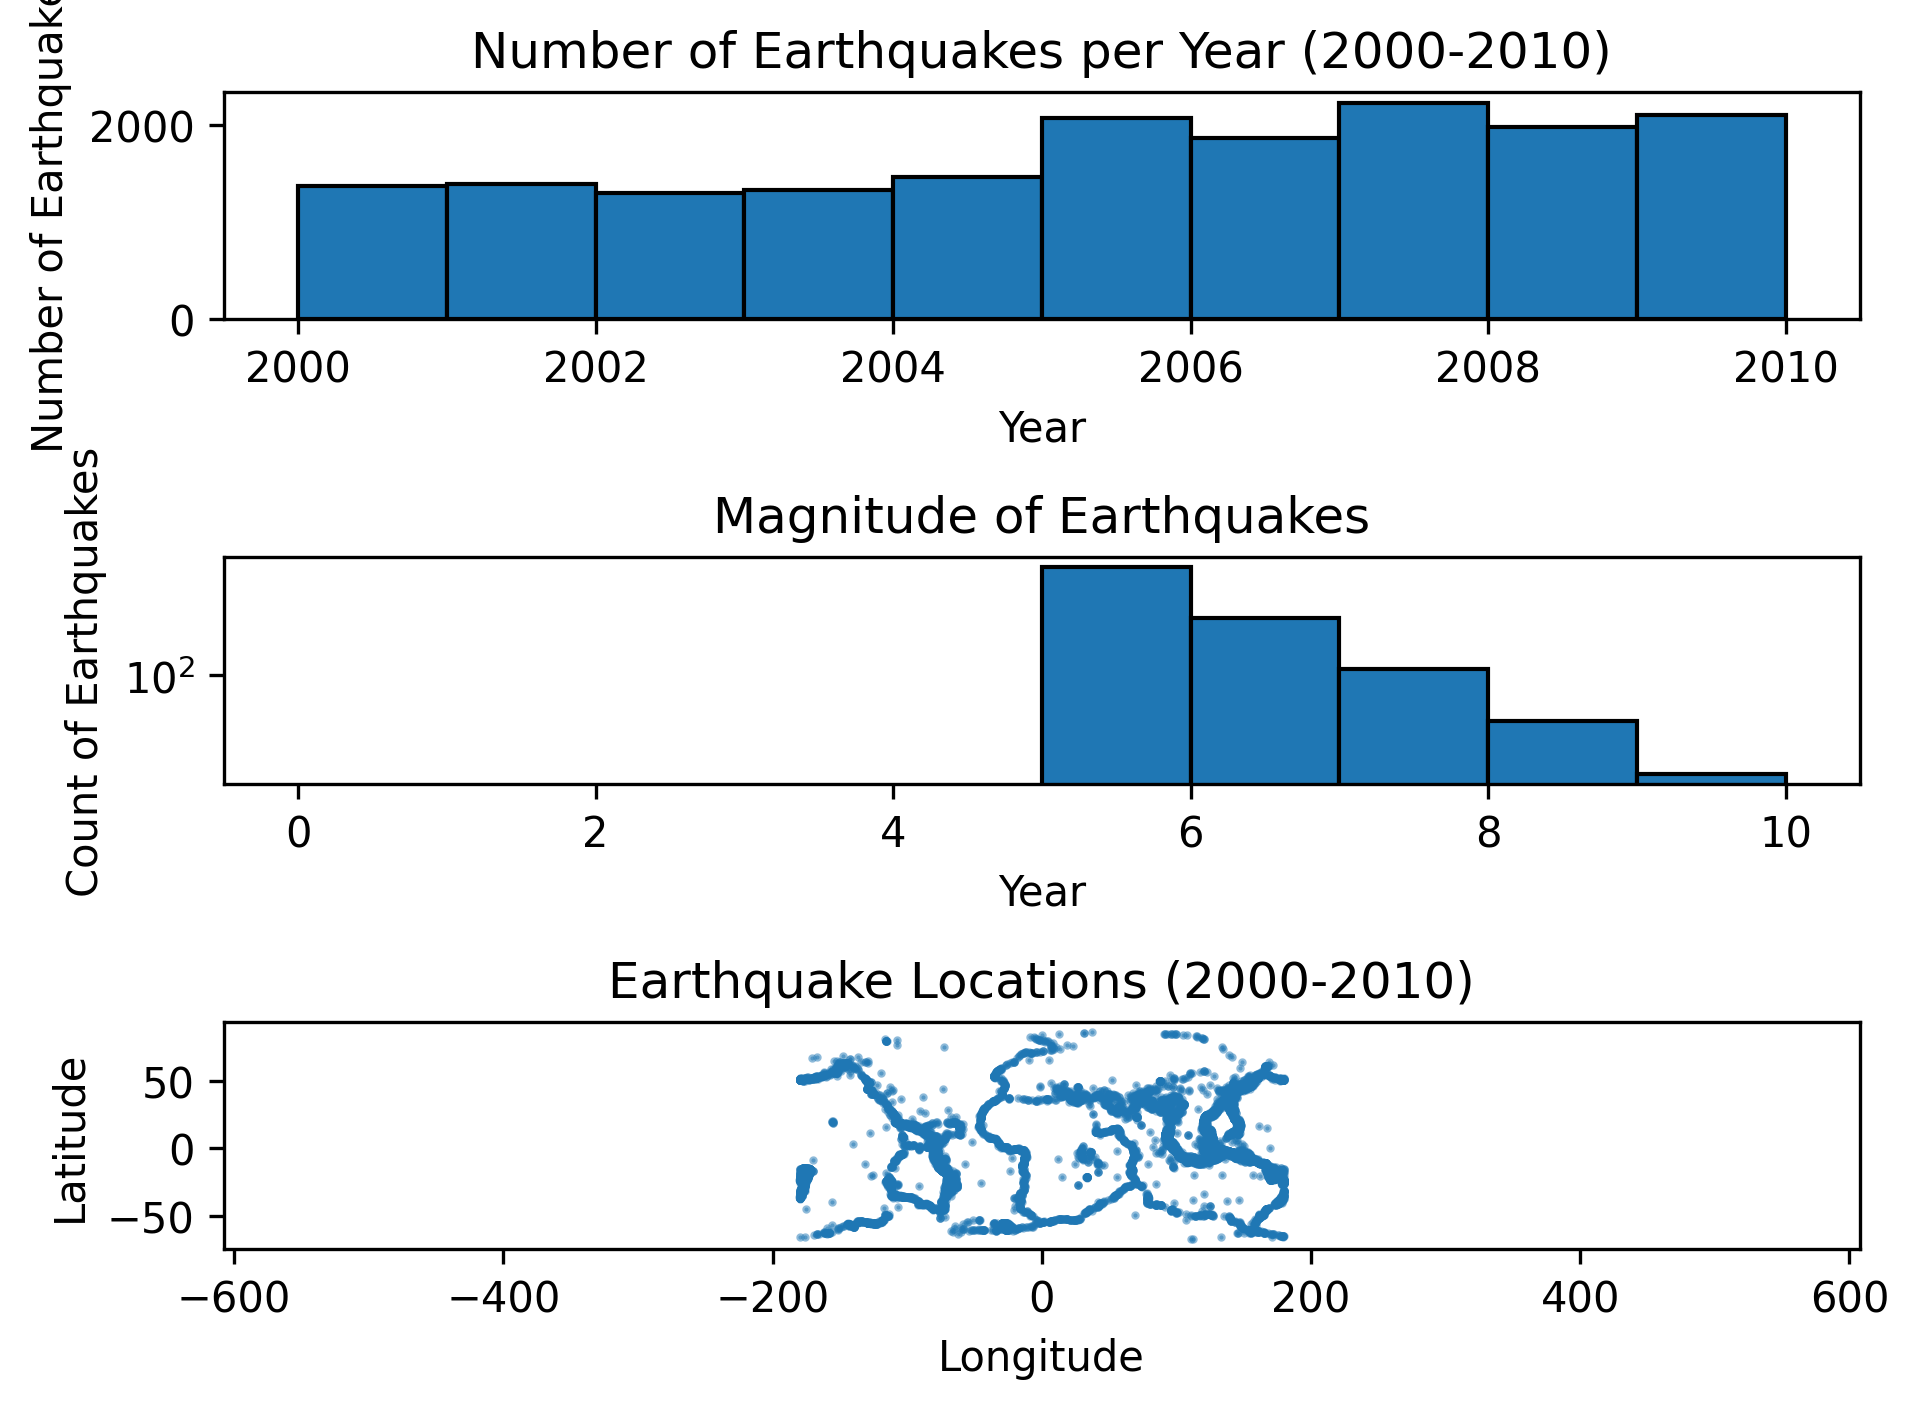

In [31]:
years, magnitudes, longitude, latitude = np.load("earthquakes.npy").T

# Earthquakes per year
bins = [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010]
plt.subplot(3, 1, 1)
plt.hist(years, bins=bins, edgecolor="black")
plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")
plt.title("Number of Earthquakes per Year (2000-2010)")

# Earthquake magnitudes
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plt.subplot(3, 1, 2)
plt.hist(magnitudes, bins=bins, edgecolor="black")
plt.yscale("log")
plt.xlabel("Year")
plt.ylabel("Count of Earthquakes")
plt.title("Magnitude of Earthquakes")

# Earthquake locations
plt.subplot(3, 1, 3)
plt.scatter(longitude, latitude, alpha=0.5, s=1)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Earthquake Locations (2000-2010)")
plt.axis("equal")

plt.tight_layout()
plt.show()

### Problem 5

The _Rosenbrock function_ is defined as $$f(x,y)=(1−x)^2 +100(y−x^2)^2$$
The minimum value of $f$ is $0$, which occurs at the point $(1, 1)$ at the bottom of a steep, banana-shaped valley of the function.

Use a heat map and a contour plot to visualize the Rosenbrock function.
Also plot the minimizer $(1, 1)$.
Use a different sequential colormap for each visualization.

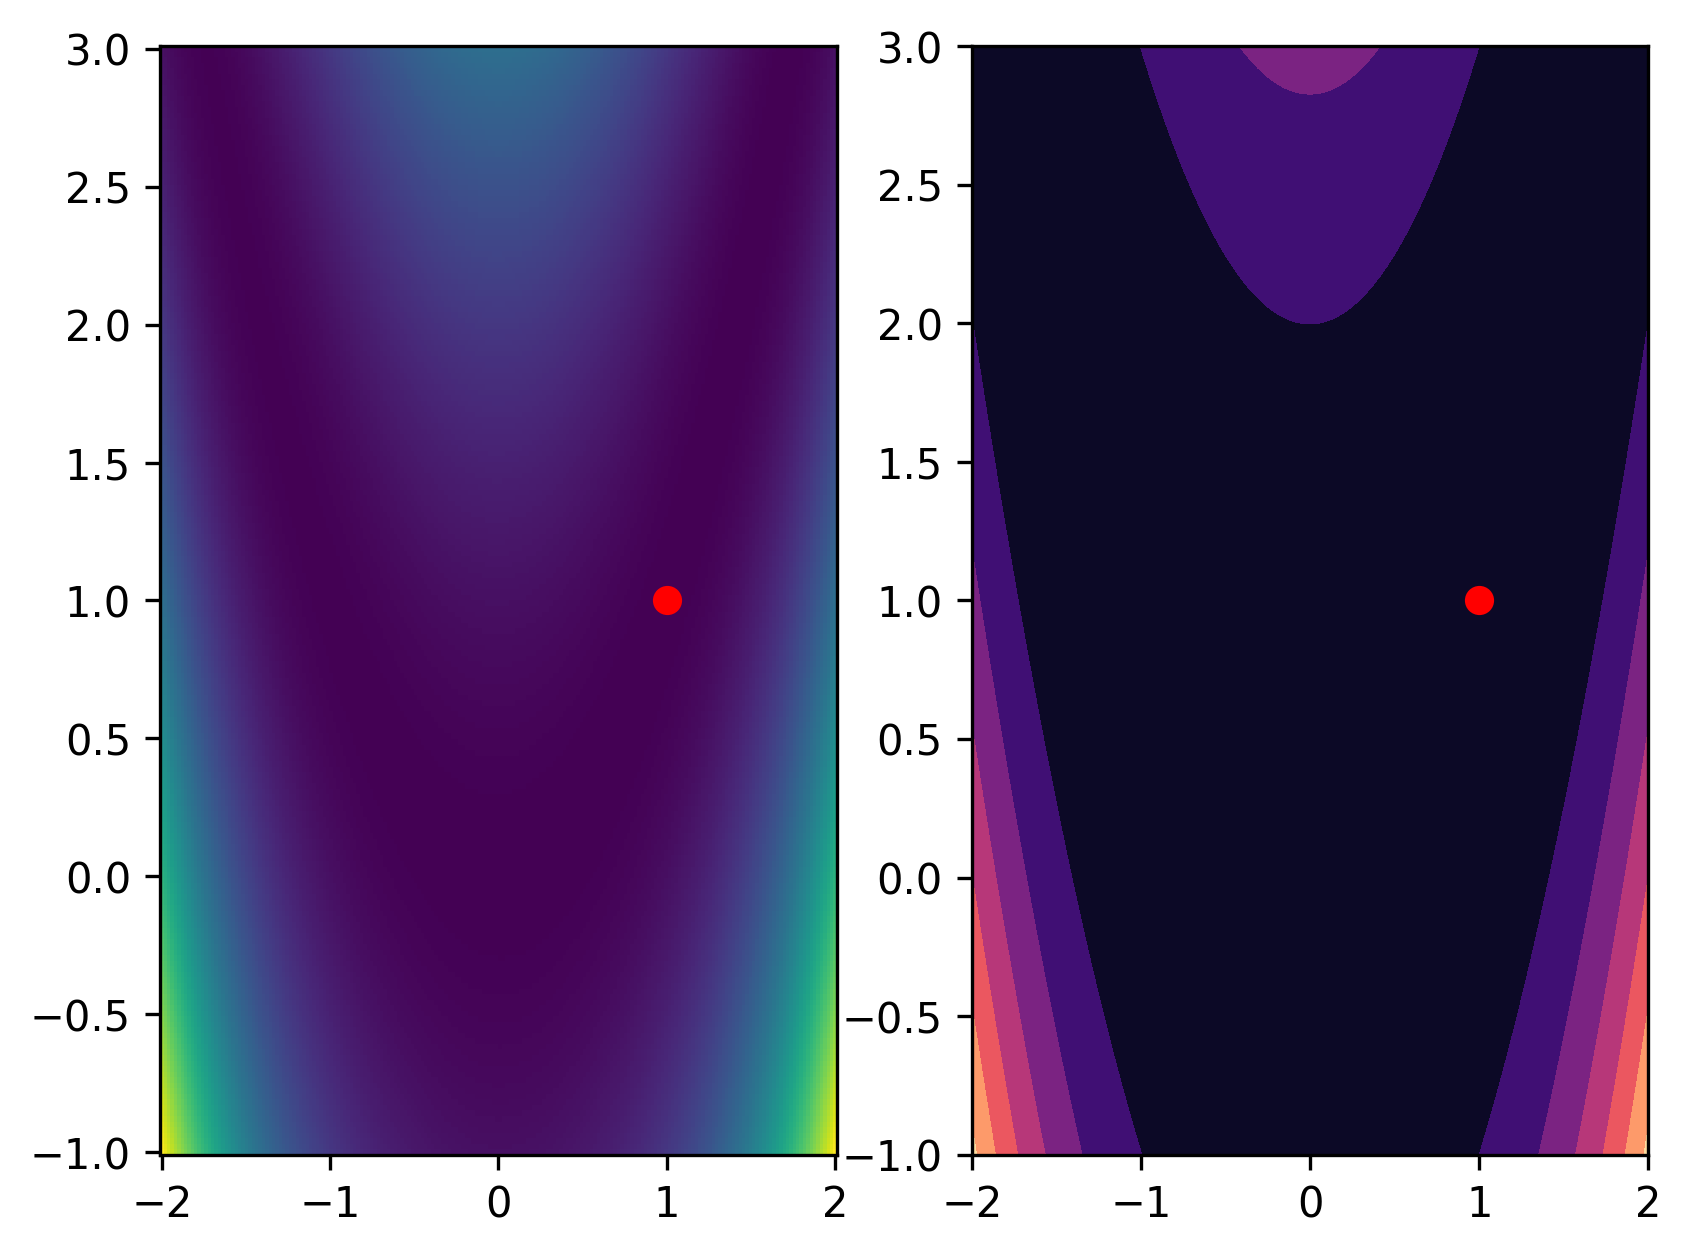

In [56]:
x = np.linspace(-2, 2, 200)
y = np.linspace(-1, 3, 200)
X, Y = np.meshgrid(x, y)
Z = (1-X)**2 + 100 * (Y - X**2)**2 # From the equation

plt.subplot(1, 2, 1)
plt.pcolormesh(X, Y, Z, cmap="viridis")
plt.scatter([1], [1], color="red") # Minimum point

plt.subplot(1, 2, 2)
plt.contourf(X, Y, Z, cmap="magma") # Different color map
plt.scatter([1], [1], color="red") # Minimum point

plt.show()

### Problem 6

The file `countries.npy` contains information from 20 different countries.
Each row in the array represents a different country; the columns are the 2015 population (in millions of people), the 2015 GDP (in billions of US dollars), the average male height (in centimeters), and the average female height (in centimeters), in that order.

Visualize this data set with at least four plots, using at least one scatter plot, one histogram, and one bar chart.
List the major insights that your visualizations reveal.

(Hint: consider using `np.argsort()` and fancy indexing to sort the data for the bar chart.)

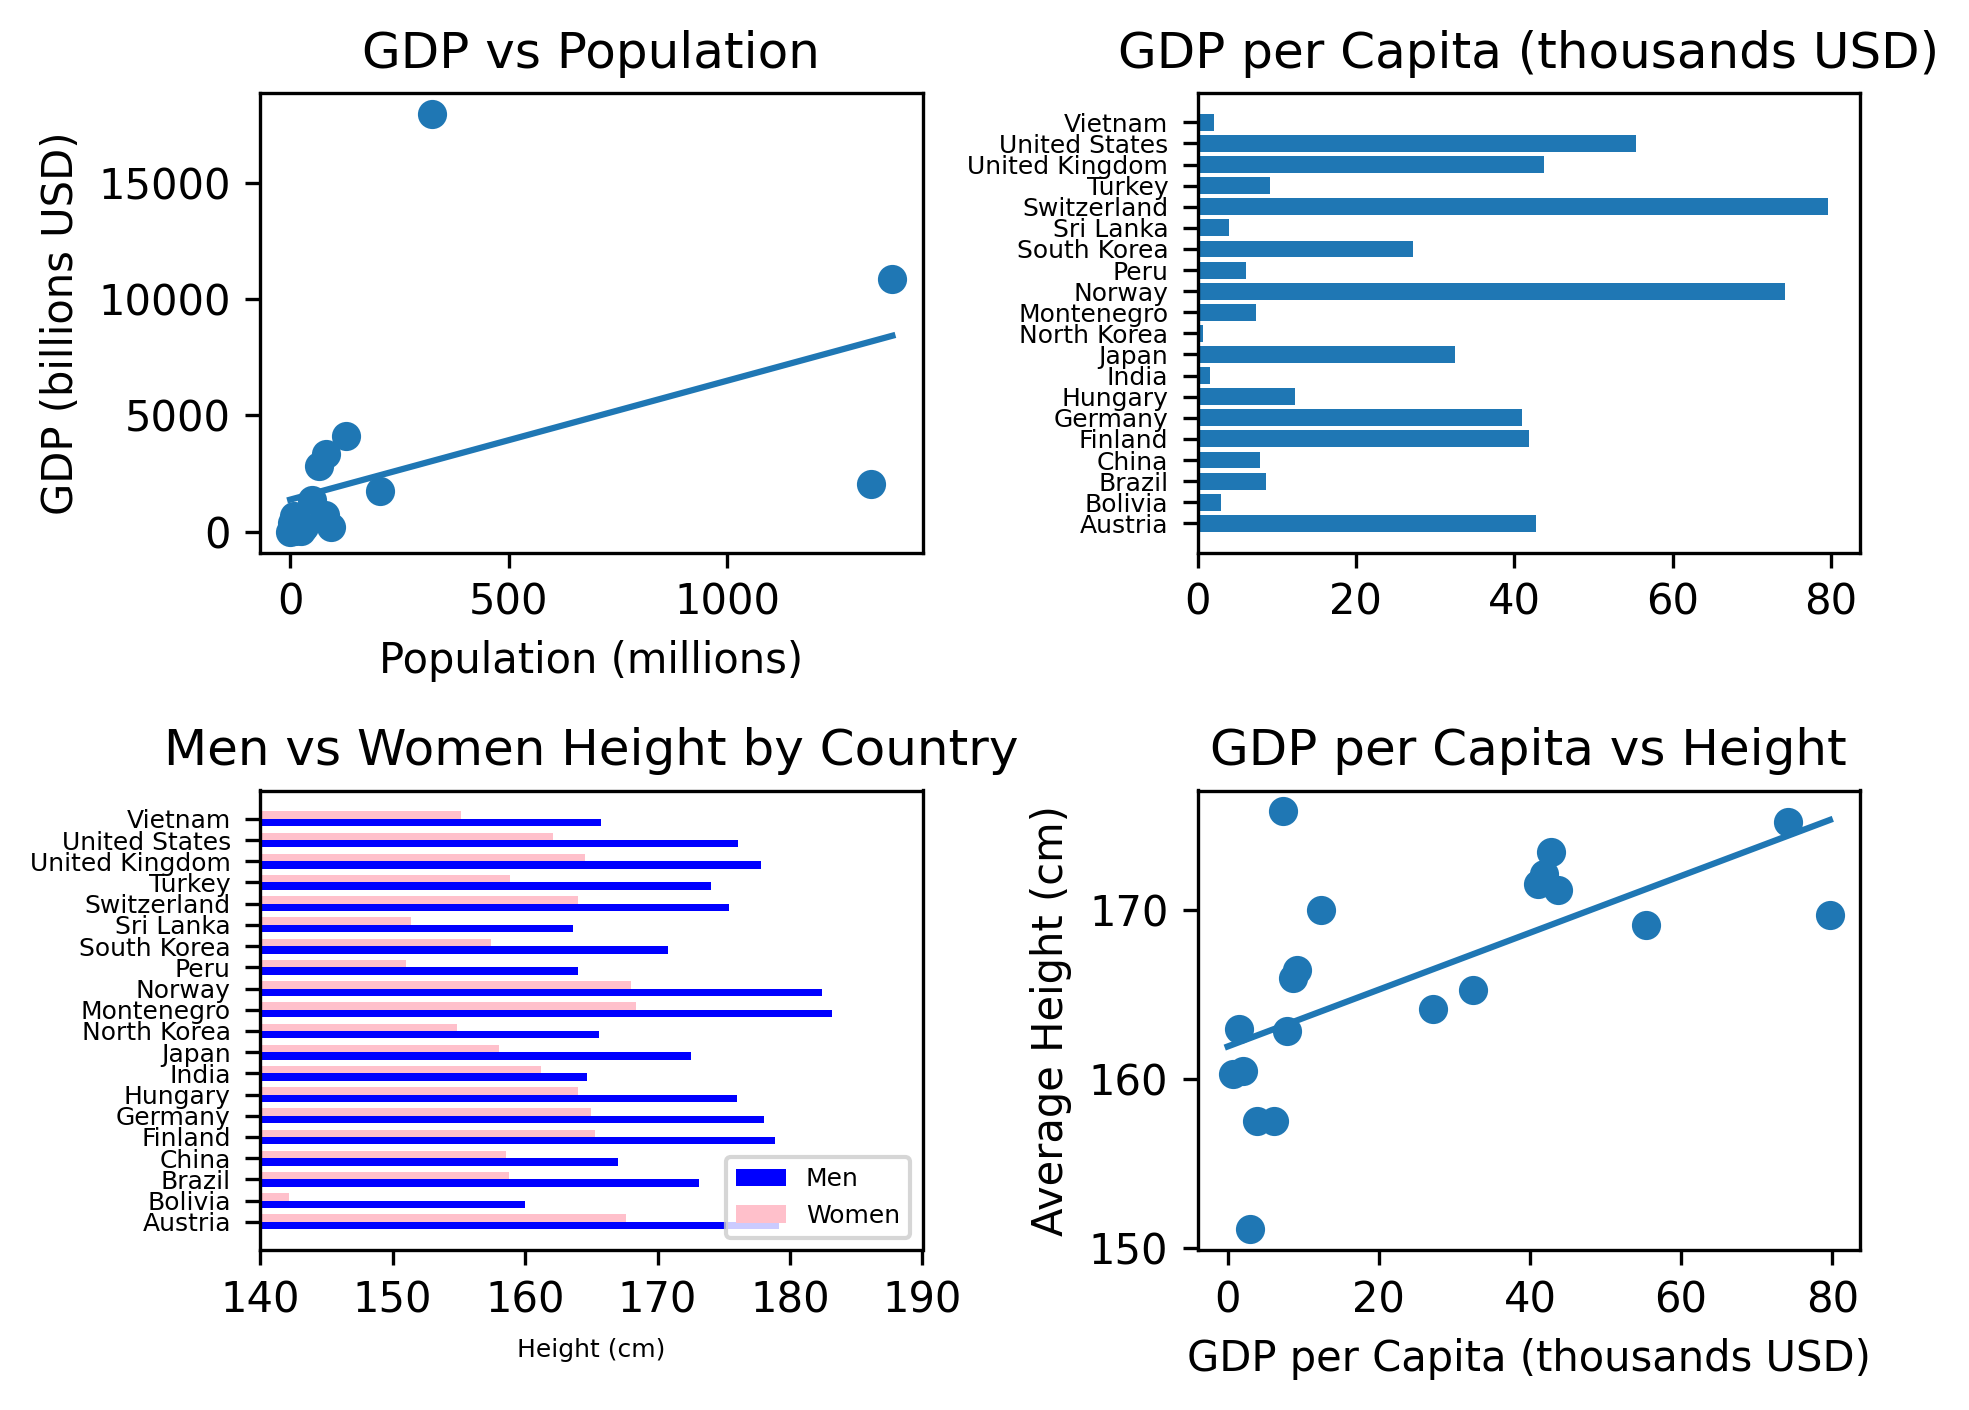

In [92]:
countries = np.array(
            ["Austria", "Bolivia", "Brazil", "China", "Finland",
             "Germany", "Hungary", "India", "Japan", "North Korea",
             "Montenegro", "Norway", "Peru", "South Korea", "Sri Lanka",
             "Switzerland", "Turkey", "United Kingdom", "United States", "Vietnam"])
population, gdp, male, female = np.load("countries.npy").T

# GDP vs Population
plt.subplot(2, 2, 1)
plt.scatter(population, gdp)
plt.xlabel("Population (millions)")
plt.ylabel("GDP (billions USD)")
plt.title("GDP vs Population")
m, b, correlation, p_value, standard_error = linregress(population, gdp) # So many variables
xs = np.linspace(0, np.max(population), 10000)
plt.plot(xs, xs * m + b) # mx + b for the win

# GDP per capita
idk = gdp / population
plt.subplot(2, 2, 2)
plt.barh(countries, idk, align="center")
plt.yticks(fontsize=6)
plt.title("GDP per Capita (thousands USD)")

# Men vs Women Height by Country
plt.subplot(2, 2, 3)
x = np.arange(len(countries))
width = 0.35 # I don't know why this works
plt.barh(x - width/2, male, width, label="Men", color="blue")
plt.barh(x + width/2, female, width, label="Women", color="pink")
plt.yticks(x, countries, fontsize=6)
plt.xlim(140, 190)
plt.xlabel("Height (cm)", fontsize=6)
plt.legend(fontsize=6) # Cuz we need a legend apparently
plt.title("Men vs Women Height by Country")

# GDP Per Capita vs Height
plt.subplot(2, 2, 4)
plt.scatter(idk, (male + female) / 2) # Average height with GDP per capita calculated earlier
plt.xlabel("GDP per Capita (thousands USD)")
plt.ylabel("Average Height (cm)")
plt.title("GDP per Capita vs Height")
m, b, _, _, _ = linregress(idk, (male + female) / 2) # This guy again
xs = np.linspace(0, np.max(idk), 10000)
plt.plot(xs, xs * m + b) # mx + b for the win

plt.tight_layout()
plt.show()